# CSCE 676 - Data Mining - Project Checkpoint 1
## Biomedical Text Mining on PubMed RCT Abstracts

## Notebook contents
- **(A)** Candidate datasets (3) with required metadata  
- **(B)** Comparative analysis table (tasks, data quality, feasibility, bias, ethics)  
- **(C)** Dataset selection
- **(D)** EDA on selected dataset
- **(E)** Initial insights & research questions  
- **(F)** Test cases
- **(G)** GitHub link & collaboration declaration

In [11]:
# Imports + settings
import os
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# (A) Identification of Candidate Datasets

Below are **three candidate healthcare datasets** I selected that:
- align with at least one **course topic**
- enable at least one **beyond-course** technique

## Dataset 1 (Selected): PubMed 200k RCT

- **Dataset name & source:** PubMed RCT dataset (Franck Dernoncourt et al.)  
  - Repo: https://github.com/Franck-Dernoncourt/pubmed-rct  
  - Paper: https://arxiv.org/abs/1710.06071  
- **Type:** Biomedical abstracts, sentence-labeled
- **Course topic alignment:** Text mining, embeddings, clustering (on text representations)
- **Beyond-course techniques:** Topic modeling (LDA/BERTopic), transformer embeddings for retrieval (e.g., PubMedBERT/SciBERT), neural ranking
- **Dataset size & structure:** ~200k abstracts; each abstract split into labeled sentences; files: `train/dev/test`
- **Data types:** sentence text, categorical sentence-role label, implicit document boundaries (abstracts)
- **Target variable(s):** sentence label (supervised) and unsupervised (topics/retrieval)
- **Licensing/usage constraints:** research dataset; derived from biomedical abstracts; use for research/education per repo/paper guidance

## Dataset 2: PubMed Central Open Access Subset (PMC OA)

- **Dataset name & source:** PubMed Central Open Access Subset (PMC OA), National Library of Medicine (NIH/NLM)  
  - Dataset page / article list: https://pmc.ncbi.nlm.nih.gov/tools/openftlist/  
  - Text mining overview: https://pmc.ncbi.nlm.nih.gov/tools/textmining/
- **Type:** Full-text biomedical articles
- **Course topic alignment:** Text mining, embeddings, clustering (full-text sections + abstracts)
- **Beyond-course techniques:** Topic modeling at scale; transformer embeddings for long documents; citation/metadata-aware retrieval; section-aware ranking
- **Dataset size & structure:** Millions of open-access full-text articles; XML/JSON formats; rich metadata (PMCIDs, journal, year)
- **Data types:** Full-text sections (Intro/Methods/Results), abstracts, titles, author metadata, citations/links (varies by article)
- **Target variable(s):** None required (unsupervised); optional labels via metadata (journal, year, MeSH/keywords where available)
- **Licensing / usage constraints:** Only OA subset is licensed for reuse; licenses vary by article (e.g., CC variants). Must respect per-article license terms when redistributing or publishing derived datasets.


## Dataset 3: BioASQ

- **Dataset name & source:** BioASQ challenge datasets (participants area)  
  - Datasets portal: https://participants-area.bioasq.org/datasets/  
  - Challenge overview: https://bioasq.org/ <br>

- **Type:** Biomedical Semantic Indexing
- **Course topic alignment:** Text mining, embeddings; graph-style analysis via linked documents/snippets (depending on task)
- **Beyond-course techniques:** Neural ranking for biomedical IR; query-document matching; retrieval evaluation (MAP/NDCG); weak supervision using provided gold snippets/PMIDs
- **Dataset size & structure:** Multiple tasks/years; QA tasks include questions + relevant documents/snippets; semantic indexing tasks include documents with MeSH terms
- **Data types:** Questions (queries), PubMed references (PMIDs), gold snippets/answers, labels (e.g., MeSH terms) depending on task
- **Target variable(s):** Task-dependent (e.g., relevant documents/snippets for QA; MeSH labels for indexing)
- **Licensing / usage constraints:** Research/education competition datasets; follow BioASQ terms and cite the dataset/task version used.


# (B) Comparative Analysis of Datasets

Comparison dimensions:
- Supported data mining topics
- Data quality issues
- Algorithmic feasibility
- Bias considerations
- Ethical considerations

In [12]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)

comparison = pd.DataFrame(

    {
       "PubMed 200k RCT (Selected)": {
        "Supported tasks (course + external)": "Course: text mining, embeddings, clustering. External: topic modeling, transformer-based semantic retrieval/ranking.",
        "Data quality issues": "Domain-specific vocabulary; abbreviations; sentence boundaries provided but text can be noisy.",
        "Algorithmic feasibility": "Feasible on laptop/Colab (abstracts/sentences). Sampling enables faster iteration.",
        "Bias considerations": "Publication and topic bias toward English, well-funded biomedical research; results reflect research writing patterns.",
        "Ethical considerations": "Public research text with no patient data; outputs interpreted as research analysis, not medical advice.",
    },

      "PMC Open Access Subset (Full Text)": {
        "Supported tasks (course + external)": "Course: text mining + embeddings + clustering at document/section level. External: large-scale topic modeling; section-aware retrieval; long-document transformers.",
        "Data quality issues": "Heterogeneous XML; formatting noise; missing sections/metadata for some articles.",
        "Algorithmic feasibility": "Very large and needs to be sampled; storage/compute heavier than abstracts; careful scoping needed.",
        "Bias considerations": "Open-access selection and language bias; some fields and journals are overrepresented.",
        "Ethical considerations": "Public articles with low privacy risk; must follow licensing and attribution requirements.",
    },
        "BioASQ (Indexing/QA)": {
            "Supported tasks (course + external)": "Course: text mining + embeddings. External: neural IR/ranking; supervised/weakly-supervised retrieval; IR evaluation metrics (MAP/NDCG).",
            "Data quality issues": "Different formats per task (factoid, list, yes/no, summary); yearly versions not fully consistent; occasional misalignment between answer snippets and source documents; some noisy or incomplete supervision.",
            "Algorithmic feasibility": "Moderate; dataset size varies by task/year; feasible to start with one task/year; works with sampling and scalable retrieval methods.",
            "Bias considerations": "Benchmark design bias; limited domain/topic coverage; expert annotation bias.",
            "Ethical considerations": "Research-only benchmark; citation required; do not claim clinical validity."
},

    }
)

display(comparison.style.set_properties(**{"white-space": "pre-wrap"}))


,PubMed 200k RCT (Selected),PMC Open Access Subset (Full Text),BioASQ (Indexing/QA)
Supported tasks (course + external),"Course: text mining, embeddings, clustering. External: topic modeling, transformer-based semantic retrieval/ranking.",Course: text mining + embeddings + clustering at document/section level. External: large-scale topic modeling; section-aware retrieval; long-document transformers.,Course: text mining + embeddings. External: neural IR/ranking; supervised/weakly-supervised retrieval; IR evaluation metrics (MAP/NDCG).
Data quality issues,Domain-specific vocabulary; abbreviations; sentence boundaries provided but text can be noisy.,Heterogeneous XML; formatting noise; missing sections/metadata for some articles.,"Different formats per task (factoid, list, yes/no, summary); yearly versions not fully consistent; occasional misalignment between answer snippets and source documents; some noisy or incomplete supervision."
Algorithmic feasibility,Feasible on laptop/Colab (abstracts/sentences). Sampling enables faster iteration.,Very large and needs to be sampled; storage/compute heavier than abstracts; careful scoping needed.,Moderate; dataset size varies by task/year; feasible to start with one task/year; works with sampling and scalable retrieval methods.
Bias considerations,"Publication and topic bias toward English, well-funded biomedical research; results reflect research writing patterns.",Open-access selection and language bias; some fields and journals are overrepresented.,Benchmark design bias; limited domain/topic coverage; expert annotation bias.
Ethical considerations,"Public research text with no patient data; outputs interpreted as research analysis, not medical advice.",Public articles with low privacy risk; must follow licensing and attribution requirements.,Research-only benchmark; citation required; do not claim clinical validity.


# (C) Dataset Selection

**Selected dataset:** **PubMed 200k RCT**

**Reasons:**

- The dataset directly supports key data mining techniques from the course, including text feature representation and clustering for discovering structure in biomedical abstracts.

- It provides a strong platform to explore advanced unsupervised methods beyond the syllabus, such as topic modeling and transformer-based embeddings, enabling deeper analysis of semantic structure.

- The dataset enables systematic comparison of multiple data mining methods, allowing evaluation of how different representations and clustering approaches reveal structure in biomedical text.

- The dataset is large enough to reveal meaningful patterns but still computationally feasible for iterative experimentation and evaluation.

**Trade-offs:**

- The dataset represents published biomedical research abstracts rather than raw clinical records, so findings describe patterns in research writing rather than real-world patient data.

- The technical vocabulary of biomedical text requires careful preprocessing and representation choices to ensure reliable clustering and interpretation.


# (D) Exploratory Data Analysis (Selected Dataset)


## 1. Data collection/Setup

In [16]:
from pathlib import Path

# Downloading PubMed 200k RCT dataset
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print("Downloading PubMed 200k RCT dataset...")

!rm -rf pubmed-rct
!git clone -q https://github.com/Franck-Dernoncourt/pubmed-rct.git

src_dir = Path("pubmed-rct") / "PubMed_200k_RCT"
assert src_dir.exists(), f"Expected folder not found: {src_dir}"

!apt-get -qq install p7zip-full

# Extract train if compressed
train_7z = src_dir / "train.7z"
if train_7z.exists():
    print("Extracting train.7z...")
    !7z x "{train_7z}" -o"{src_dir}"

# Copy dataset files
for fname in ["train.txt", "dev.txt", "test.txt"]:
    f = src_dir / fname
    assert f.exists(), f"{fname} not found after download."
    !cp "{f}" "{DATA_DIR}/"

# ✅ define file paths for later cells
train_path = DATA_DIR / "train.txt"
dev_path   = DATA_DIR / "dev.txt"
test_path  = DATA_DIR / "test.txt"


print("Dataset ready:", sorted([p.name for p in DATA_DIR.glob('*')]))


Extracting train.7z...

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 66928396 bytes (64 MiB)

Extracting archive: pubmed-rct/PubMed_200k_RCT/train.7z
--
Path = pubmed-rct/PubMed_200k_RCT/train.7z
Type = 7z
Physical Size = 66928396
Headers Size = 121
Method = LZMA:26
Solid = -
Blocks = 1

  0%      3% - train.txt                  7% - train.txt                 10% - train.txt                 14% - train.txt                 17% - train.txt                 21% - train.txt                 24% - train.txt                 28% - train.txt

In [17]:
def parse_pubmed_rct(path: Path) -> pd.DataFrame:
    # Parses PubMed RCT files:
    # - Abstract IDs are lines starting with ###
    # - Abstracts are separated by blank lines
    # - Content lines are: LABEL<TAB>TEXT
    # Returns columns: label, text, sent_idx, abstract_idx

    rows = []
    abstract_idx = -1
    sent_idx = 0

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line == "":
                sent_idx = 0
                continue

            if line.startswith("###"):
                abstract_idx += 1
                sent_idx = 0
                continue

            if "\t" in line:
                label, text = line.split("\t", 1)
                rows.append((label, text, sent_idx, abstract_idx))
                sent_idx += 1

    return pd.DataFrame(rows, columns=["label", "text", "sent_idx", "abstract_idx"])

In [18]:
df_train = parse_pubmed_rct(train_path)
df_train["split"] = "train"

df_dev = parse_pubmed_rct(dev_path)
df_dev["split"] = "dev"

df_test = parse_pubmed_rct(test_path)
df_test["split"] = "test"

df = pd.concat([df_train, df_dev, df_test], ignore_index=True)
df.head()

,label,text,sent_idx,abstract_idx,split
0,BACKGROUND,"The emergence of HIV as a chronic condition means that people living with HIV are required to take more responsibility for the self-management of their condition , including making physical , emotional and social adjustments .",0,0,train
1,BACKGROUND,"This paper describes the design and evaluation of Positive Outlook , an online program aiming to enhance the self-management skills of gay men living with HIV .",1,0,train
2,METHODS,This study is designed as a randomised controlled trial in which men living with HIV in Australia will be assigned to either an intervention group or usual care control group .,2,0,train
3,METHODS,The intervention group will participate in the online group program ` Positive Outlook ' .,3,0,train
4,METHODS,"The program is based on self-efficacy theory and uses a self-management approach to enhance skills , confidence and abilities to manage the psychosocial issues associated with HIV in daily life .",4,0,train


In [19]:
print("Full dataset shape:", df.shape)
df.info()

Full dataset shape: (2270286, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2270286 entries, 0 to 2270285
Data columns (total 5 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   label         object
 1   text          object
 2   sent_idx      int64 
 3   abstract_idx  int64 
 4   split         object
dtypes: int64(2), object(3)
memory usage: 86.6+ MB


**2. Data dictionary**
- **split**: train/dev/test file source  
- **label**: rhetorical role of the sentence (BACKGROUND, OBJECTIVE, METHODS, RESULTS, CONCLUSIONS)  
- **text**: raw sentence text  
- **sent_idx**: sentence index within an abstract (0-based)  
- **abstract_idx**: running abstract index within each split

**3. Missingness and duplicate analysis** <br>
I check for missing values and duplicate rows to understand the basic data quality. This helps ensure the dataset is clean and that later analysis is not affected by incomplete or repeated data.

In [20]:
# Missingness & duplicates
print("Missingness rate by column:")
display(df.isna().mean().sort_values(ascending=False))

print("\nFull-row duplicates:", df.duplicated().sum())
print("Duplicate (label,text) pairs:", df.duplicated(subset=["label", "text"]).sum())

Missingness rate by column:


,0
label,0.0
text,0.0
sent_idx,0.0
abstract_idx,0.0
split,0.0



Full-row duplicates: 0
Duplicate (label,text) pairs: 28717


**Insight from above code cell** <br>
There are no missing values or exact duplicate rows in the dataset, and the repeated (label, text) pairs come from common sentences that appear in many biomedical abstracts, not from data errors.

**4. Cleaning decisions**
- **Light normalization** (lowercasing and whitespace normalization) reduces accidental token differences for EDA and IR baselines,
  while preserving biomedical terminology.
- **Exact duplicates** are removed (if present) to avoid overweighting repeated sentences.
- I avoid aggressive stemming/stopword removal at this stage because biomedical meaning can be lost (e.g., "no", "without").

In [21]:
def clean_text(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

df["text_clean"] = df["text"].apply(clean_text)

before = df.shape[0]
df = df.drop_duplicates(subset=["split", "abstract_idx", "sent_idx", "label", "text_clean"]).reset_index(drop=True)
after = df.shape[0]

print(f"Rows before dedup: {before:,} | after: {after:,} | dropped: {before-after:,}")
df.head()

Rows before dedup: 2,270,286 | after: 2,270,286 | dropped: 0


,label,text,sent_idx,abstract_idx,split,text_clean
0,BACKGROUND,"The emergence of HIV as a chronic condition means that people living with HIV are required to take more responsibility for the self-management of their condition , including making physical , emotional and social adjustments .",0,0,train,"the emergence of hiv as a chronic condition means that people living with hiv are required to take more responsibility for the self-management of their condition , including making physical , emotional and social adjustments ."
1,BACKGROUND,"This paper describes the design and evaluation of Positive Outlook , an online program aiming to enhance the self-management skills of gay men living with HIV .",1,0,train,"this paper describes the design and evaluation of positive outlook , an online program aiming to enhance the self-management skills of gay men living with hiv ."
2,METHODS,This study is designed as a randomised controlled trial in which men living with HIV in Australia will be assigned to either an intervention group or usual care control group .,2,0,train,this study is designed as a randomised controlled trial in which men living with hiv in australia will be assigned to either an intervention group or usual care control group .
3,METHODS,The intervention group will participate in the online group program ` Positive Outlook ' .,3,0,train,the intervention group will participate in the online group program ` positive outlook ' .
4,METHODS,"The program is based on self-efficacy theory and uses a self-management approach to enhance skills , confidence and abilities to manage the psychosocial issues associated with HIV in daily life .",4,0,train,"the program is based on self-efficacy theory and uses a self-management approach to enhance skills , confidence and abilities to manage the psychosocial issues associated with hiv in daily life ."


**5. Label Distribution Analysis** <br>
I look at how often each sentence label appears in the dataset to understand how balanced it is.

Most sentences belong to the METHODS and RESULTS categories, while OBJECTIVE and BACKGROUND appear less often. This imbalance could affect clustering and retrieval results, since models may focus more on the larger categories. Knowing this helps interpret later analysis more carefully.

,count
label,
RESULTS,786524
METHODS,741896
CONCLUSIONS,348536
BACKGROUND,201927
OBJECTIVE,191403


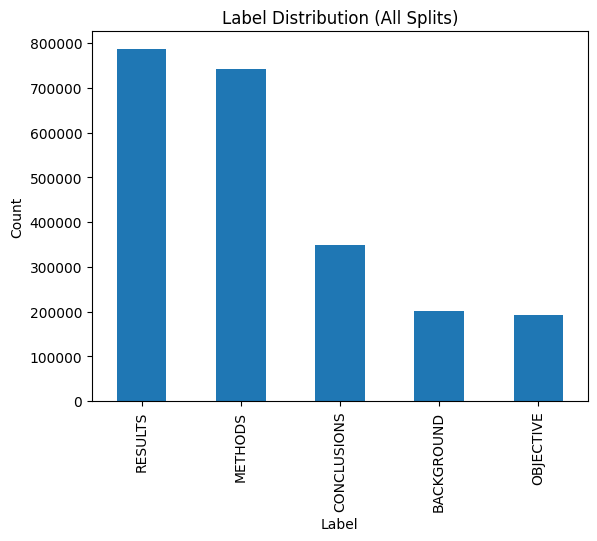

In [22]:
# Label distribution
label_counts = df["label"].value_counts()
display(label_counts)

label_counts.plot(kind="bar")
plt.title("Label Distribution (All Splits)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

**Insight from above code cell** <br>
The label distribution shows some imbalance, with METHODS and RESULTS appearing more often than other categories. This reflects the natural structure of biomedical abstracts and highlights the importance of considering class balance when interpreting clustering and retrieval results

**6. Sentence Length Analysis** <br>
I examine the distribution of sentence lengths (in words and characters) to understand how much sentences vary in size.Some variation is important because sentence length can affect text representation and clustering performance in later analysis. Sentence length affects embedding quality and model performance, and extreme values may indicate noise or preprocessing challenges.

,char_len,word_count
count,2.270286e+06,2.270286e+06
mean,1.505220e+02,2.622870e+01
std,7.667082e+01,1.508749e+01
min,2.000000e+00,1.000000e+00
25%,9.700000e+01,1.600000e+01
50%,1.380000e+02,2.300000e+01
75%,1.890000e+02,3.300000e+01
max,1.813000e+03,3.380000e+02


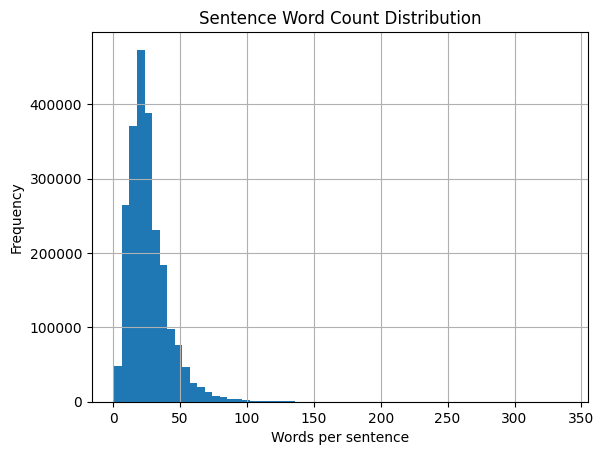

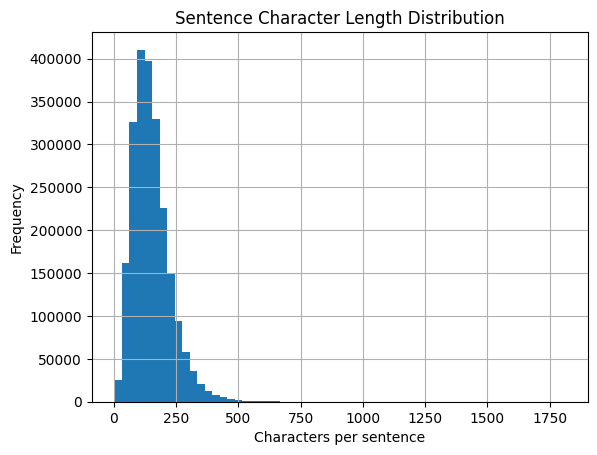

In [23]:
# Sentence length distributions
df["char_len"] = df["text_clean"].str.len()
df["word_count"] = df["text_clean"].str.split().apply(len)

display(df[["char_len", "word_count"]].describe())

df["word_count"].hist(bins=60)
plt.title("Sentence Word Count Distribution")
plt.xlabel("Words per sentence")
plt.ylabel("Frequency")
plt.show()

df["char_len"].hist(bins=60)
plt.title("Sentence Character Length Distribution")
plt.xlabel("Characters per sentence")
plt.ylabel("Frequency")
plt.show()

**Insight from above code cell** <br>
Most sentences are medium length, with an average of about 26 words. The wide spread in sentence lengths shows that some sentences are much longer than others, which can affect how text features and embeddings behave. This suggests that models should handle variable sentence lengths carefully during later analysis.

**7. Vocabulary Snapshot** <br>
I take a quick sample of the training data to look at the most common words in the dataset. This helps me understand the general vocabulary used in biomedical abstracts and check for very frequent or repetitive terms.

In [24]:
# Quick vocabulary snapshot (sampled for speed)
train_rows = df[df["split"] == "train"]
sample_n = min(30000, len(train_rows))
sample_df = train_rows.sample(sample_n, random_state=RANDOM_SEED)

tokens = " ".join(sample_df["text_clean"]).split()
top_tokens = Counter(tokens).most_common(30)
top_tokens

[(',', 30987),
 ('.', 29853),
 ('the', 29591),
 ('of', 23314),
 ('and', 22582),
 (')', 20486),
 ('(', 20384),
 ('in', 18313),
 ('to', 12442),
 ('with', 10184),
 ('a', 10040),
 ('were', 8765),
 ('was', 8082),
 ('%', 7695),
 ('patients', 6950),
 ('for', 6541),
 ('group', 5693),
 ('=', 4941),
 ('p', 4746),
 ('or', 4393),
 ('at', 4028),
 ('study', 3244),
 ('on', 3168),
 ('treatment', 3116),
 (';', 3101),
 ('after', 2850),
 ('by', 2690),
 ('is', 2395),
 ('groups', 2294),
 ('<', 2258)]

**Insight from above code cell** <br>
The most frequent tokens are common English words (like “the”, “of”, “and”) along with some biomedical terms (like “patients”, “study”, “treatment”). This shows that the dataset contains both general language and domain-specific vocabulary. It suggests that simple keyword matching may miss deeper meaning, motivating the use of semantic embeddings and topic modeling later in the project.

**8. TF-IDF Feature Sparsity** <br>
Biomedical text produces high-dimensional sparse representations. We quantify sparsity to assess computational feasibility and structure of the feature space.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['text'])

sparsity = 1.0 - (X.nnz / (X.shape[0] * X.shape[1]))
print(f"TF-IDF matrix sparsity: {sparsity:.4f}")


TF-IDF matrix sparsity: 0.9978


**Insight from above code cell** <br>
The TF-IDF matrix is extremely sparse (~99.8% zeros), which is typical for text data with many unique words. Most sentences use only a small portion of the total vocabulary. While sparse representations are efficient to store and compute, this sparsity also motivates exploring dense embedding methods later in the project to better capture semantic relationships.

**9. Preliminary Clustering Analysis** <br>
We perform an initial clustering experiment to test whether meaningful structure exists in the text representation space.

In [26]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# TF-IDF max_features is high, thus lowering
k = 8
mbk = MiniBatchKMeans(
    n_clusters=k,
    random_state=42,
    batch_size=2048,
    n_init="auto",
    max_iter=100
)

labels = mbk.fit_predict(X)

rng = np.random.RandomState(42)
sample_size = min(5000, X.shape[0])
sample_idx = rng.choice(X.shape[0], size=sample_size, replace=False)

sil = silhouette_score(X[sample_idx], labels[sample_idx], metric="cosine")
print(f"MiniBatchKMeans k={k} | silhouette (sampled, cosine) = {sil:.4f}")


MiniBatchKMeans k=8 | silhouette (sampled, cosine) = 0.0107


**Insight from above code cell** <br>
The very low silhouette score (~0.01) shows that TF-IDF + KMeans does not form clear clusters, suggesting we may need better semantic representations like embeddings later in the project.

### Bias Considerations

The dataset consists of published biomedical research abstracts, which introduces several likely biases. **First**, publication bias may be present, since studies with positive or novel findings are more likely to be published than negative or null results. **Second**, the label distribution shows that METHODS and RESULTS sentences dominate the dataset, which may bias clustering and retrieval toward these sections. **Third**, biomedical literature may overrepresent well-funded research areas and diseases common in high-income settings.

These biases mean that results from this project reflect patterns in research writing rather than clinical reality, and conclusions should be interpreted in that context.


### Ethical Considerations

The dataset contains publicly available biomedical abstracts and does not include personal or patient identifiers. However, because the domain is healthcare, results must be interpreted carefully. The system developed in this project is intended as a research and information retrieval tool, not as medical advice. Outputs will be framed as exploratory analysis of research text, and no clinical claims will be made.


# (E) Initial Insights from Exploratory Data Analysis

The exploratory analysis reveals several patterns that guide the next steps of the project.

First, the label distribution is clearly imbalanced, with METHODS and RESULTS sentences appearing much more often than the other sections. This imbalance may influence clustering and retrieval results, since models could focus more on the dominant sentence types.

Second, sentence lengths follow a right-skewed distribution. Most sentences are fairly short, but there is a noticeable tail of very long sentences. This variation can affect how well different text representations work, since both TF-IDF and embedding methods must handle sentences with very different levels of detail.

The TF-IDF feature matrix is extremely sparse (about 99.8% zeros), which is typical for high-dimensional text data. While sparse representations are efficient, this also suggests that dense embedding methods may capture semantic relationships more effectively.

Finally, an initial clustering experiment produces a low silhouette score, indicating that sentence clusters are not strongly separated using basic TF-IDF features. This suggests that richer semantic representations may be needed to uncover meaningful structure in biomedical text.


**Hypothesis Motivating Beyond-Course Techniques**

Biomedical abstracts contain specialized terminology, synonyms, and complex writing patterns that are not fully captured by simple keyword-based representations. Methods like TF-IDF rely on word overlap and may miss deeper semantic structure in the data.

I hypothesize that transformer-based embeddings and topic modeling will reveal clearer latent structure in biomedical text. These methods should produce more meaningful clusters and themes than TF-IDF alone, enabling better organization and analysis of the dataset.

### Potential Research Questions

- How do TF-IDF and transformer embeddings compare in their ability to produce well-separated clusters of biomedical sentences?

- Can topic modeling identify coherent biomedical themes and reveal meaningful structure in the dataset?

- Does the discovered structure vary across rhetorical sentence labels (e.g., METHODS vs RESULTS)?


# (F) GitHub Portfolio Building

**Public GitHub repo link:**
- https://github.com/sibalgurmehar/CSCE676_Project_BiomedicalTextMining

## Test Cases
The tests below verify:

1. The parser produced non-empty train/dev/test splits (sanity check)

2. Labels match the expected set (data integrity check)

3. Required columns exist with no missing values and valid index fields (schema and consistency check)

In [27]:
# TESTS

# TEST 1: Non-empty splits (basic parsing sanity)
assert df_train.shape[0] > 0, "Train split parsed to an empty dataframe."
assert df_dev.shape[0] > 0, "Dev split parsed to an empty dataframe."
assert df_test.shape[0] > 0, "Test split parsed to an empty dataframe."

# TEST 2: Label set sanity (schema validation)
expected_labels = {"BACKGROUND", "OBJECTIVE", "METHODS", "RESULTS", "CONCLUSIONS"}
labels_seen = set(df["label"].unique())
unexpected = labels_seen - expected_labels
assert len(unexpected) == 0, f"Unexpected labels found: {unexpected}"

# TEST 3: No missing core fields + basic index validity
# These columns are required for later analysis and represent the dataset schema.
required_cols = ["label", "text", "sent_idx", "abstract_idx", "split"]
for c in required_cols:
    assert c in df.columns, f"Missing required column: {c}"

# No nulls in core fields
null_rates = df[required_cols].isna().mean()
assert (null_rates == 0).all(), f"Null values found in core columns: {null_rates[null_rates > 0].to_dict()}"

# Basic index sanity: sentence index should be non-negative and abstract index should be non-negative
assert (df["sent_idx"] >= 0).all(), "Found negative sent_idx values."
assert (df["abstract_idx"] >= 0).all(), "Found negative abstract_idx values."

print("All validation tests passed.")


All validation tests passed.


**Test Results Interpretation**

All validation tests passed successfully. This confirms that the dataset splits were parsed correctly and contain data, the sentence labels match the expected schema, and there are no missing values in the core columns used for analysis. The checks on index fields also verify that sentence and abstract identifiers are valid. Together, these tests increase confidence that the dataset is well-structured and suitable for the exploratory analysis and modeling steps that follow.

# Collaboration Declaration

1. Collaborators: None

2. Web sources:

PubMed RCT dataset repository: https://github.com/Franck-Dernoncourt/pubmed-rct

PubMed RCT paper: https://arxiv.org/abs/1710.06071

PMC OA subset: https://pmc.ncbi.nlm.nih.gov/tools/openftlist/

PMC text mining overview: https://pmc.ncbi.nlm.nih.gov/tools/textmining/

BioASQ datasets portal: https://participants-area.bioasq.org/datasets/

scikit-learn documentation (TF-IDF, clustering, silhouette score):
https://scikit-learn.org/stable/documentation.html

pandas documentation (data manipulation and EDA):
https://pandas.pydata.org/docs/

matplotlib documentation (visualization):
https://matplotlib.org/stable/users/index.html

3. AI tools:

ChatGPT was used to help understand which factors could be used to compare candidate datasets during project selection. During exploratory data analysis, it also suggested trying clustering to examine dataset structure. When the initial clustering code ran slowly, ChatGPT helped identify a practical solution by suggesting sampling the data to improve performance.

4. Citations for papers used:

- Dernoncourt, F., Lee, J. Y., & Szolovits, P. (2017). *PubMed 200k RCT: a dataset for sequential sentence classification in medical abstracts.* arXiv:1710.06071. https://arxiv.org/abs/1710.06071

- PubMed Central Open Access Subset (PMC OA), U.S. National Library of Medicine (NIH/NLM). https://pmc.ncbi.nlm.nih.gov/tools/openftlist/

- Tsatsaronis, G., Balikas, G., Malakasiotis, P., Partalas, I., Zschunke, M., Alvers, M. R., … & Paliouras, G. (2015). *An overview of the BIOASQ large-scale biomedical semantic indexing and question answering competition.* BMC Bioinformatics. https://bioasq.org/

